# GCN Fraud Detection on Elliptic++ Dataset

This notebook implements a **Graph Convolutional Network (GCN)** for Bitcoin fraud detection using the Elliptic++ dataset.

## Pipeline
1. Load & preprocess Elliptic++ (transactions + actors)
2. Build PyG `Data` objects per time step
3. Train a GCN with temporal split (steps 1–34 train, 35–49 test)
4. Evaluate: F1 (illicit), Precision, Recall, AUC-ROC
5. Visualize results

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['font.size'] = 12
plt.style.use('ggplot')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, BatchNorm
from torch_geometric.utils import to_undirected

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

# ── Paths ──
DATA_DIR = '../data/raw/elliptic_bitcoin_data'
FIG_DIR  = '../outputs/figures/elliptic_bitcoin_data'
MODEL_DIR = '../outputs/models'
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Auto-detect nested subfolder
for candidate in [DATA_DIR, os.path.join(DATA_DIR, 'elliptic_bitcoin_dataset')]:
    if os.path.isfile(os.path.join(candidate, 'elliptic_txs_features.csv')):
        DATA_DIR = candidate
        break

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Data   : {os.path.abspath(DATA_DIR)}')

Device : cpu
PyTorch: 2.4.1
Data   : /Users/kuijun/Desktop/spring-2026-spec-proj/data/raw/elliptic_bitcoin_data/elliptic_bitcoin_dataset


## 1. Load Data

In [2]:
# ── Load raw CSVs ──
features_df = pd.read_csv(
    os.path.join(DATA_DIR, 'elliptic_txs_features.csv'),
    header=None,
    dtype={0: np.int64, **{i: np.float32 for i in range(1, 167)}}
)
classes_df  = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_classes.csv'))
edgelist_df = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_edgelist.csv'))

# Column naming: col-0 = txId, col-1 = time_step, cols 2..94 = local, 95..166 = agg
NUM_AGG   = 72
NUM_LOCAL = features_df.shape[1] - 2 - NUM_AGG   # 93
feat_names = (
    ['txId', 'time_step']
    + [f'local_{i}' for i in range(NUM_LOCAL)]
    + [f'agg_{i}'   for i in range(NUM_AGG)]
)
features_df.columns = feat_names

# Merge class labels
df = features_df.merge(classes_df, on='txId', how='left')
df['label'] = df['class'].map({'1': 1, '2': 0, 'unknown': -1}).astype(int)

print(f'Features : {features_df.shape}')
print(f'Edgelist : {edgelist_df.shape}')
print(f'Classes  : {df["label"].value_counts().to_dict()}  (1=illicit, 0=licit, -1=unknown)')

Features : (203769, 167)
Edgelist : (234355, 2)
Classes  : {-1: 157205, 0: 42019, 1: 4545}  (1=illicit, 0=licit, -1=unknown)


## 2. Preprocessing & Graph Construction

In [3]:
# ── Feature columns (local + aggregated) ──
FEAT_COLS = [c for c in df.columns if c.startswith('local_') or c.startswith('agg_')]
print(f'Feature dimension: {len(FEAT_COLS)}')

# ── Global node index mapping  txId → integer index ──
all_tx_ids = df['txId'].values
tx2idx = {tx: i for i, tx in enumerate(all_tx_ids)}

# ── Scale features (fit on labeled training nodes only) ──
TRAIN_STEPS = list(range(1, 35))   # time steps 1-34  (~70 %)
TEST_STEPS  = list(range(35, 50))  # time steps 35-49 (~30 %)

train_mask = df['time_step'].isin(TRAIN_STEPS)
scaler = StandardScaler()
scaler.fit(df.loc[train_mask, FEAT_COLS].values)

X_scaled = scaler.transform(df[FEAT_COLS].values).astype(np.float32)
print('Feature scaling done.')

# ── Build edge_index (global, directed → convert to undirected) ──
src = edgelist_df['txId1'].map(tx2idx).dropna().astype(int).values
dst = edgelist_df['txId2'].map(tx2idx).dropna().astype(int).values

# Keep only edges where BOTH endpoints are in our node set
valid_mask = (
    edgelist_df['txId1'].isin(tx2idx) &
    edgelist_df['txId2'].isin(tx2idx)
).values
src = edgelist_df.loc[valid_mask, 'txId1'].map(tx2idx).values.astype(np.int64)
dst = edgelist_df.loc[valid_mask, 'txId2'].map(tx2idx).values.astype(np.int64)

edge_index = torch.tensor(np.stack([src, dst], axis=0), dtype=torch.long)
edge_index = to_undirected(edge_index)   # symmetrise
print(f'Edge index shape: {edge_index.shape}  (undirected)')

Feature dimension: 165
Feature scaling done.
Edge index shape: torch.Size([2, 468710])  (undirected)


In [4]:
# ── Build a SINGLE global PyG Data object ──
# Masks: train  = labeled nodes in train steps
#        test   = labeled nodes in test steps
#        (unlabeled nodes with label==-1 are included as neighbours but excluded from loss)

labels = torch.tensor(df['label'].values, dtype=torch.long)
x      = torch.tensor(X_scaled, dtype=torch.float)

train_mask_t = torch.tensor(
    (df['time_step'].isin(TRAIN_STEPS) & (df['label'] != -1)).values, dtype=torch.bool
)
test_mask_t  = torch.tensor(
    (df['time_step'].isin(TEST_STEPS)  & (df['label'] != -1)).values, dtype=torch.bool
)

data = Data(
    x          = x,
    edge_index = edge_index,
    y          = labels,
    train_mask = train_mask_t,
    test_mask  = test_mask_t,
)
data = data.to(DEVICE)

print(data)
print(f'Train labeled nodes: {train_mask_t.sum().item():,}')
print(f'Test  labeled nodes: {test_mask_t.sum().item():,}')

# Class imbalance weight for loss
y_train = labels[train_mask_t]
n_licit   = (y_train == 0).sum().item()
n_illicit = (y_train == 1).sum().item()
pos_weight = torch.tensor([n_licit / n_illicit], dtype=torch.float).to(DEVICE)
print(f'Illicit/Licit in train: {n_illicit:,} / {n_licit:,}  →  pos_weight = {pos_weight.item():.2f}')

Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], test_mask=[203769])
Train labeled nodes: 29,894
Test  labeled nodes: 16,670
Illicit/Licit in train: 3,462 / 26,432  →  pos_weight = 7.63


## 3. GCN Model Definition

In [5]:
class GCN(nn.Module):
    """
    3-layer GCN with:
      - BatchNorm after each conv
      - Dropout for regularisation
      - Skip connection from input to final layer
    """
    def __init__(self, in_channels, hidden_channels, out_channels=2,
                 dropout=0.4, num_layers=3):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        dims = [in_channels] + [hidden_channels] * (num_layers - 1) + [hidden_channels]
        for i in range(num_layers):
            self.convs.append(GCNConv(dims[i], dims[i + 1]))
            self.bns.append(BatchNorm(dims[i + 1]))

        # Final classifier head
        self.lin = nn.Linear(hidden_channels + in_channels, out_channels)

    def forward(self, x, edge_index):
        x0 = x  # keep for skip connection
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        # Skip connection
        x = torch.cat([x, x0], dim=-1)
        return self.lin(x)


# ── Hyper-parameters ──
IN_CHANNELS     = len(FEAT_COLS)   # 165
HIDDEN_CHANNELS = 128
NUM_LAYERS      = 3
DROPOUT         = 0.4
LR              = 1e-3
WEIGHT_DECAY    = 5e-4
EPOCHS          = 200
PATIENCE        = 20

model = GCN(
    in_channels     = IN_CHANNELS,
    hidden_channels = HIDDEN_CHANNELS,
    num_layers      = NUM_LAYERS,
    dropout         = DROPOUT,
).to(DEVICE)

optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

# Weighted cross-entropy to handle class imbalance
# weight[0]=licit, weight[1]=illicit
class_weight = torch.tensor([1.0, pos_weight.item()], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

GCN(
  (convs): ModuleList(
    (0): GCNConv(165, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (lin): Linear(in_features=293, out_features=2, bias=True)
)

Trainable parameters: 55,628


## 4. Training

In [6]:
def train_epoch(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out    = model(data.x, data.edge_index)
    probs  = F.softmax(out[mask], dim=-1)[:, 1].cpu().numpy()
    preds  = out[mask].argmax(dim=-1).cpu().numpy()
    labels = data.y[mask].cpu().numpy()
    f1  = f1_score(labels, preds, pos_label=1, zero_division=0)
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0
    return f1, auc, preds, probs, labels


# ── Training loop ──
history = {'loss': [], 'train_f1': [], 'test_f1': [], 'test_auc': []}
best_test_f1   = 0.0
best_epoch     = 0
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, data, optimizer, criterion)
    tr_f1, tr_auc, _, _, _ = evaluate(model, data, data.train_mask)
    te_f1, te_auc, _, _, _ = evaluate(model, data, data.test_mask)

    scheduler.step(te_f1)

    history['loss'].append(loss)
    history['train_f1'].append(tr_f1)
    history['test_f1'].append(te_f1)
    history['test_auc'].append(te_auc)

    if te_f1 > best_test_f1:
        best_test_f1   = te_f1
        best_epoch     = epoch
        patience_count = 0
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'gcn_elliptic_best.pt'))
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Loss {loss:.4f} | '
              f'Train F1 {tr_f1:.4f} | Test F1 {te_f1:.4f} | Test AUC {te_auc:.4f}')

print(f'\nBest Test F1 = {best_test_f1:.4f} at epoch {best_epoch}')

Epoch   1 | Loss 0.8135 | Train F1 0.2587 | Test F1 0.1103 | Test AUC 0.5485
Epoch  20 | Loss 0.3027 | Train F1 0.5770 | Test F1 0.2303 | Test AUC 0.8467
Early stopping at epoch 36

Best Test F1 = 0.2410 at epoch 16


## 5. Evaluation

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'gcn_elliptic_best.pt'), map_location=DEVICE))

_, _, preds_test, probs_test, labels_test = evaluate(model, data, data.test_mask)
_, _, preds_train, probs_train, labels_train = evaluate(model, data, data.train_mask)

print('=' * 55)
print('TEST SET — Classification Report')
print('=' * 55)
print(classification_report(labels_test, preds_test, target_names=['Licit', 'Illicit']))

test_f1  = f1_score(labels_test, preds_test, pos_label=1, zero_division=0)
test_prec = precision_score(labels_test, preds_test, pos_label=1, zero_division=0)
test_rec  = recall_score(labels_test, preds_test, pos_label=1, zero_division=0)
test_auc  = roc_auc_score(labels_test, probs_test)

print(f'Illicit F1        : {test_f1:.4f}')
print(f'Illicit Precision : {test_prec:.4f}')
print(f'Illicit Recall    : {test_rec:.4f}')
print(f'ROC-AUC           : {test_auc:.4f}')

TEST SET — Classification Report
              precision    recall  f1-score   support

       Licit       0.98      0.63      0.77     15587
     Illicit       0.14      0.86      0.24      1083

    accuracy                           0.65     16670
   macro avg       0.56      0.75      0.51     16670
weighted avg       0.93      0.65      0.74     16670

Illicit F1        : 0.2410
Illicit Precision : 0.1401
Illicit Recall    : 0.8596
ROC-AUC           : 0.8138


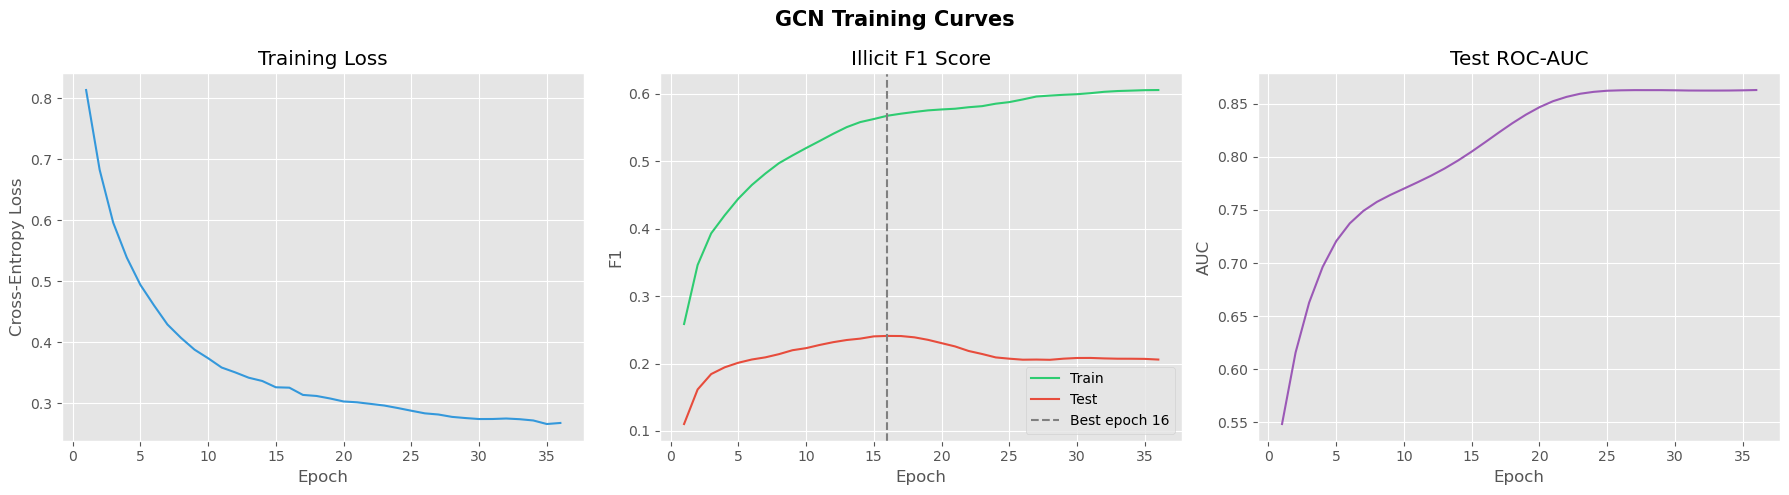

In [8]:
# ── Training Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GCN Training Curves', fontsize=15, fontweight='bold')

epochs_range = range(1, len(history['loss']) + 1)

axes[0].plot(epochs_range, history['loss'], color='#3498db')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')

axes[1].plot(epochs_range, history['train_f1'], label='Train', color='#2ecc71')
axes[1].plot(epochs_range, history['test_f1'],  label='Test',  color='#e74c3c')
axes[1].axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch {best_epoch}')
axes[1].set_title('Illicit F1 Score')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend()

axes[2].plot(epochs_range, history['test_auc'], color='#9b59b6')
axes[2].set_title('Test ROC-AUC')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gcn_training_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

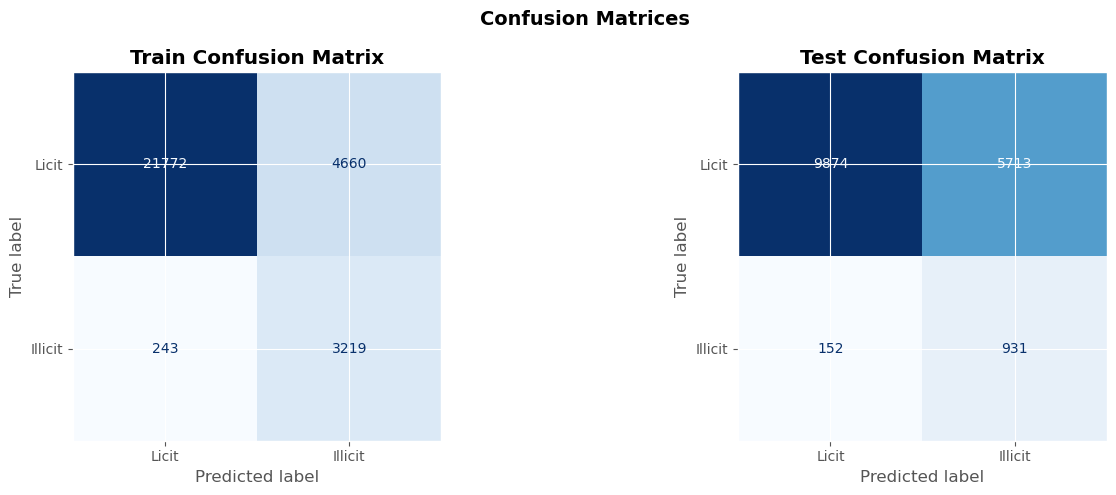

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, preds, labels, title in [
    (axes[0], preds_train, labels_train, 'Train'),
    (axes[1], preds_test,  labels_test,  'Test'),
]:
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Licit', 'Illicit'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gcn_confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.show()

 step       f1  precision   recall      auc
   35 0.413551   0.262611 0.972527 0.897079
   36 0.102970   0.055085 0.787879 0.764523
   37 0.368664   0.225989 1.000000 0.883352
   38 0.394366   0.253886 0.882883 0.782289
   39 0.320000   0.195122 0.888889 0.849074
   40 0.333333   0.216578 0.723214 0.809283
   41 0.326118   0.195841 0.974138 0.808945
   42 0.411765   0.263840 0.937238 0.905160
   43 0.077253   0.040724 0.750000 0.768759
   44 0.035305   0.018034 0.833333 0.503590
   45 0.013129   0.006637 0.600000 0.654934
   46 0.012579   0.006369 0.500000 0.473239
   47 0.084291   0.046025 0.500000 0.696767
   48 0.328042   0.202614 0.861111 0.838761
   49 0.118519   0.074766 0.285714 0.449107


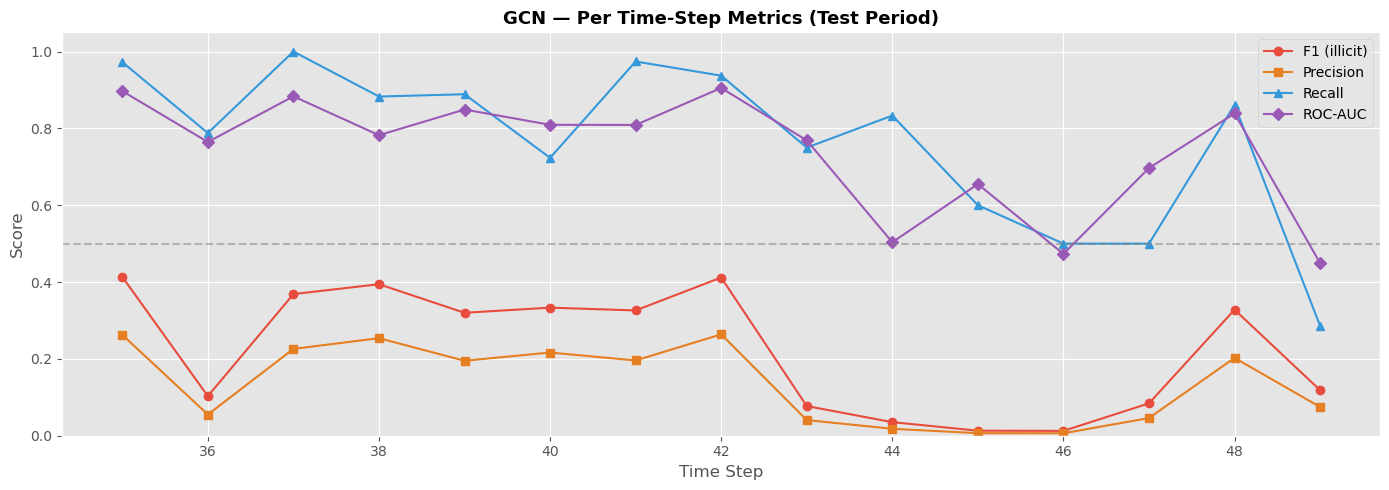

In [10]:
# ── F1 per Time Step (test period) ──
model.eval()
with torch.no_grad():
    out_all   = model(data.x, data.edge_index)
    preds_all = out_all.argmax(dim=-1).cpu().numpy()
    probs_all = F.softmax(out_all, dim=-1)[:, 1].cpu().numpy()

labels_all = df['label'].values
steps_all  = df['time_step'].values

step_metrics = []
for s in TEST_STEPS:
    mask_s = (steps_all == s) & (labels_all != -1)
    if mask_s.sum() == 0:
        continue
    y_s = labels_all[mask_s]
    p_s = preds_all[mask_s]
    pr_s = probs_all[mask_s]
    if len(np.unique(y_s)) < 2:
        continue
    step_metrics.append({
        'step': s,
        'f1':        f1_score(y_s, p_s, pos_label=1, zero_division=0),
        'precision': precision_score(y_s, p_s, pos_label=1, zero_division=0),
        'recall':    recall_score(y_s, p_s, pos_label=1, zero_division=0),
        'auc':       roc_auc_score(y_s, pr_s),
    })

metrics_df = pd.DataFrame(step_metrics)
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(metrics_df['step'], metrics_df['f1'],        marker='o', label='F1 (illicit)',  color='#e74c3c')
ax.plot(metrics_df['step'], metrics_df['precision'], marker='s', label='Precision',     color='#e67e22')
ax.plot(metrics_df['step'], metrics_df['recall'],    marker='^', label='Recall',        color='#3498db')
ax.plot(metrics_df['step'], metrics_df['auc'],       marker='D', label='ROC-AUC',       color='#9b59b6')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('GCN — Per Time-Step Metrics (Test Period)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step'); ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gcn_per_step_metrics.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Summary

In [11]:
print('=' * 55)
print('GCN on Elliptic++ — Final Summary')
print('=' * 55)
print(f'Architecture  : {NUM_LAYERS}-layer GCN + skip connection')
print(f'Hidden dim    : {HIDDEN_CHANNELS}')
print(f'Features      : {IN_CHANNELS}')
print(f'Train steps   : 1–34')
print(f'Test  steps   : 35–49')
print(f'Best epoch    : {best_epoch}')
print()
print(f'Test Illicit F1        : {test_f1:.4f}')
print(f'Test Illicit Precision : {test_prec:.4f}')
print(f'Test Illicit Recall    : {test_rec:.4f}')
print(f'Test ROC-AUC           : {test_auc:.4f}')
print()
print(f'Per-step mean F1  : {metrics_df["f1"].mean():.4f} ± {metrics_df["f1"].std():.4f}')
print(f'Per-step mean AUC : {metrics_df["auc"].mean():.4f} ± {metrics_df["auc"].std():.4f}')

GCN on Elliptic++ — Final Summary
Architecture  : 3-layer GCN + skip connection
Hidden dim    : 128
Features      : 165
Train steps   : 1–34
Test  steps   : 35–49
Best epoch    : 16

Test Illicit F1        : 0.2410
Test Illicit Precision : 0.1401
Test Illicit Recall    : 0.8596
Test ROC-AUC           : 0.8138

Per-step mean F1  : 0.2227 ± 0.1593
Per-step mean AUC : 0.7390 ± 0.1530
